In [ ]:
! huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) ى
Invalid input. Must be one of ('y', 'yes', '1', 'n', 'no', '0', '')
Add token as git credential? (Y/n) n
Token is valid (permission: read).
The token `aya` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been save

In [ ]:
!pip install bitsandbytes
!pip install transformers accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
! pip install transformers sentence-transformers faiss-cpu accelerate bitsandbytes langdetect fastapi uvicorn pyngrok nest_asyncio



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 37.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.8 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=69e81a7892d45d52627885ff39d648201dffecba790d4f444002ad42fa655fb3
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [ ]:
import json
import faiss
import numpy as np
import re
import logging
import torch
from typing import List, Tuple, Dict, Optional
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from langdetect import detect

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

class DataLoader:
    def __init__(self, json_path: str):
        self.json_path = json_path
        self.qa_pairs: List[Tuple[str, str]] = []
        self.instructions: List[str] = []

    def load(self) -> Tuple[List[Tuple[str, str]], List[str]]:
        try:
            with open(self.json_path, "r", encoding="utf-8") as f:
                data = json.load(f)
            self._parse_json(data)
            return self.qa_pairs, self.instructions
        except (FileNotFoundError, json.JSONDecodeError) as e:
            logger.error(f"Error loading JSON data: {e}")
            raise

    def _parse_json(self, data: dict) -> None:
        for category, content in data.items():
            try:
                if isinstance(content, list):
                    for entry in content:
                        if isinstance(entry, dict):
                            question = entry.get("Q") or entry.get("question")
                            answer = entry.get("A") or entry.get("answer")
                            if isinstance(answer, list):
                                answer = " ".join(answer)
                            if question and answer:
                                self.qa_pairs.append((question, answer))
                        elif isinstance(entry, list):
                            for sub_entry in entry:
                                question = sub_entry.get("question")
                                answer = sub_entry.get("answer")
                                if isinstance(answer, list):
                                    answer = " ".join(answer)
                                if question and answer:
                                    self.qa_pairs.append((question, answer))
                        else:
                            self.instructions.append(str(entry))
                elif isinstance(content, dict):
                    for value in content.values():
                        if isinstance(value, dict):
                            question = value.get("question")
                            answer = value.get("answer")
                            if isinstance(answer, list):
                                answer = " ".join(answer)
                            if question and answer:
                                self.qa_pairs.append((question, answer))
                        elif isinstance(value, list):
                            self.instructions.extend(value)
                        else:
                            self.instructions.append(str(value))
            except Exception as e:
                logger.warning(f"Error processing category '{category}': {e}")

        logger.info(f"Loaded {len(self.qa_pairs)} Q&A pairs and {len(self.instructions)} instructions.")


class EmbeddingPipeline:
    def __init__(self, qa_pairs: List[Tuple[str, str]], instructions: List[str]):
        self.qa_pairs = qa_pairs
        self.instructions = instructions
        self.embedder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
        self.index = None
        self.all_data: List[Tuple[str, str]] = []

    def build_index(self) -> None:
        question_embeddings = self.embedder.encode([q[0] for q in self.qa_pairs])
        instruction_embeddings = self.embedder.encode(self.instructions)

        dimension = question_embeddings.shape[1]
        self.index = faiss.IndexFlatL2(dimension)
        self.index.add(np.array(question_embeddings))
        self.index.add(np.array(instruction_embeddings))
        self.all_data = self.qa_pairs + [(inst, inst) for inst in self.instructions]
        logger.info(f"FAISS index built with {len(self.all_data)} entries.")

    def retrieve(self, query: str, top_k: int = 3, threshold: float = 0.7) -> Tuple[List[str], List[str]]:
        """Retrieve the closest matching answer from FAISS, including instructions and Q&A pairs."""
        try:

            user_embedding = self.embedder.encode([query])
            user_embedding = np.array(user_embedding)
            user_embedding = user_embedding.astype(np.float32)
            _, indices = self.index.search(user_embedding, top_k)


            retrieved_answers = []
            retrieved_instructions = []


            for idx in indices[0]:
                if 0 <= idx < len(self.qa_pairs):

                    retrieved_answers.append(self.qa_pairs[idx][1])
                elif len(self.qa_pairs) <= idx < len(self.all_data):

                    if self.all_data[idx][1] in self.instructions:
                        retrieved_instructions.append(self.all_data[idx][1])
                    else:
                        retrieved_answers.append(self.all_data[idx][1])

            # Check if any results meet the threshold, if not, return a fallback message
            if not retrieved_answers and not retrieved_instructions:
                return ["I'm sorry, I couldn't find specific information on that. Can you provide more details?"], []

            return retrieved_instructions, retrieved_answers

        except Exception as e:
            logger.error(f"Error retrieving data: {e}")
            return [], []



class TextGenerator:
    def __init__(self):
        self.tokenizer = AutoTokenizer.from_pretrained("CohereForAI/aya-expanse-8b", timeout=600)
        self.model = AutoModelForCausalLM.from_pretrained("CohereForAI/aya-expanse-8b", load_in_4bit=True, device_map="auto")
        self.pipeline = pipeline("text-generation", model=self.model, tokenizer=self.tokenizer)

    def generate(self, prompt: str, min_length: int, max_length: int) -> str:
        try:
            outputs = self.pipeline(
                prompt,
                max_length=max_length,
                min_length=min_length,
                do_sample=True,
                top_p=0.85,
                temperature=0.7,
                eos_token_id=self.tokenizer.eos_token_id
            )
            return outputs[0]['generated_text'].replace(prompt, "").strip()
        except Exception as e:
            logger.error(f"Error generating text: {e}")
            return ""


class ChatbotPipeline:
    def __init__(self, json_path: str):
        data_loader = DataLoader(json_path)
        qa_pairs, instructions = data_loader.load()

        self.user_conversations: Dict[str, List[str]] = {}
        self.embedding = EmbeddingPipeline(qa_pairs, instructions)
        self.embedding.build_index()
        self.generator = TextGenerator()

    def get_dynamic_word_range(self, user_input: str, retrieved_answers: List[str]) -> Tuple[int, int]:
        try:
            language = detect(user_input)
        except:
            language = "en"

        num_retrieved = sum(len(ans.split()) for ans in retrieved_answers)
        avg_len = num_retrieved + len(user_input.split())

        language_factors = {
            "en": 1.0, "ar": 0.8, "fr": 1.1, "zh": 0.5, "es": 1.05,
            "de": 1.0, "ru": 1.1, "it": 1.0, "pt": 1.05, "ja": 0.6, "ko": 0.7, "tr": 0.9
        }
        factor = language_factors.get(language, 1.0)

        base_max_len = int((avg_len + 30) * factor)
        return max(150, base_max_len - 100), max(600, base_max_len + 200)

    def format_response(self, text: str) -> str:
        text = re.sub(r"<\|im_end\|>|<\|endoftext\|>", "", text).strip()
        text = re.sub(r"\n", "", text).strip()
        paragraphs = text.split("\n")
        lines = []
        for paragraph in paragraphs:
            line = ""
            for word in paragraph.split():
                if len(line) + len(word) > 90:
                    lines.append(line.strip())
                    line = ""
                line += f"{word} "
            if line:
                lines.append(line.strip())
        return "\n".join(lines)

    def add_bullets(self, text: str) -> str:
        lines = text.split("\n")
        return "\n".join([f"- {line.strip()}" if re.match(r"^\d+\.|^-", line) else line for line in lines])

    def clear_conclusion(self, text: str) -> str:
        lines = text.split("\n")
        if lines:
            for phrase in ["Conclusion:", "Summary:", "Final Thoughts:"]:
                if lines[-1].startswith(phrase):
                    lines[-1] = lines[-1][len(phrase):].strip()
        return "\n".join(lines)

    def generate_response(self, user_id: str, user_input: str) -> str:
        if user_id not in self.user_conversations:
            self.user_conversations[user_id] = []

        self.user_conversations[user_id].append(f"User: {user_input}")
        retrieved_instructions, retrieved_answers = self.embedding.retrieve(user_input)


        #if retrieved_answers and len(retrieved_answers[0].split()) < 50:
         #   return retrieved_answers[0]


        context_parts = retrieved_instructions[:2] + retrieved_answers[:2]  # Take top 2 of each if available
        context = " ".join(context_parts) if context_parts else ""

        min_chars, max_chars = self.get_dynamic_word_range(user_input, retrieved_answers)
        history = "\n".join(self.user_conversations[user_id][-5:])

        prompt = f"""
        You are an AI assistant specialized in answering questions.
        - Use provided context when available.
        - Ensure responses are **detailed but concise**.
        - Use **bullet points** when listing details.
        - Do not repeat information unnecessarily.
        - Maintain a **conversational tone**.

        {'Context: ' + context if context else 'No specific context available.'}

        Conversation history:
        {history}

        User question: {user_input}
        Answer:
        """

        response = self.generator.generate(prompt, min_chars, max_chars)
        response = self.format_response(response)
        response = self.add_bullets(response)
        response = self.clear_conclusion(response)

        if response and response[-1] not in ".!?":
            response += "."

        self.user_conversations[user_id].append(f"Chatbot: {response}")
        return response
    def start_chat(self, user_id: str = "user1") -> None:
        print("Start chatting with the AI! Type 'exit' or 'quit' to stop.\n")
        while True:
            user_input = input("You: ")
            if user_input.lower() in ["exit", "quit"]:
                print("Chat ended.")
                break
            response = self.generate_response(user_id=user_id, user_input=user_input)
            print(f"Bot: {response}\n")




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pipeline = ChatbotPipeline("/content/drive/MyDrive/DATA_RQ.json")
pipeline.start_chat()


In [ ]:
# Load the 150 evaluation questions
with open("/content/drive/MyDrive/evaluation_questions_rag.json", "r", encoding="utf-8") as f:
    questions_data = json.load(f)

questions = questions_data["questions"]

# Store evaluation results
evaluation_results = []

# Loop through questions
for q in questions:
    try:
        # Retrieve context using the pipeline
        retrieved_instructions, retrieved_answers = pipeline.embedding.retrieve(q)
        context = " ".join(retrieved_instructions[:2] + retrieved_answers[:2])  # keep it consistent with main logic

        # Generate response using the pipeline method
        answer = pipeline.generate_response(user_id="eval_user", user_input=q)

        evaluation_results.append({
            "question": q,
            "retrieved_context": context,
            "generated_response": answer,
            "score": ""  # You will fill this manually later
        })

        print(f"Processed: {q}")

    except Exception as e:
        print(f"Failed for: {q}")
        print(e)


Processed: I'm a woman traveling alone to Morocco, is it safe?
Processed: Is hugging people okay in Tunisia?
Processed: Do I need to take my shoes off in Jordanian homes?
Processed: Am I allowed to wear sleeveless in a religious place in the UAE?
Processed: What's the right thing to wear at a mosque in Dubai?
Processed: Where can I find halal food in Lebanon, and is tipping expected?
Processed: Are there any customs around photography in Egypt?
Processed: Is it common to share meals with strangers in Jordan?
Processed: Can I drink alcohol in Tunisia as a tourist?
Processed: what should a tourist know or do when visiting mosques in arab countries?
Processed: What are common mistakes tourists make regarding dining & eating etiquette in arab culture?
Processed: What are the traditions in rural Arab areas?
Processed: where to go in Egypt if i want spiritual retreat?
Processed: Recommend a good restaurant in Egypt
Processed: Tell me about Ramadan in Arab countries
Processed: Do people usual

ERROR:__main__:Error generating text: Input length of input_ids is 500, but `max_length` is set to 500. This can lead to unexpected behavior. You should consider increasing `max_length` or, better yet, setting `max_new_tokens`.


Processed: What are the conversation etiquette rules in Arab culture?
Processed: What are the greeting customs in Arab countries?
Processed: Is it acceptable to ask personal questions in Arab culture?


ERROR:__main__:Error generating text: Input length of input_ids is 500, but `max_length` is set to 500. This can lead to unexpected behavior. You should consider increasing `max_length` or, better yet, setting `max_new_tokens`.


Processed: How should a disagreement be handled in Arab culture?
Processed: How can I find top attractions in Arab cities using Tajawul?
Processed: What if I want to explore specific cultural events in Arab countries?
Processed: Is there any way to see past trips or travel insights on Tajawal, or is that not an option?
Processed: What exactly does Tajawal provide, and is it worth using?
Processed: How should someone handle their travel bookings and schedule—does Tajawal help with that?


ERROR:__main__:Error generating text: Input length of input_ids is 500, but `max_length` is set to 500. This can lead to unexpected behavior. You should consider increasing `max_length` or, better yet, setting `max_new_tokens`.


Processed: Can RafiQ actually help uncover lesser-known spots in a foreign country, or is it just for mainstream recommendations?
Processed: What's the most reliable method for getting instant translations when traveling, if any?
Processed: Does RafiQ really help with finding unique cultural experiences in Arab countries, or is it limited?
Processed: What kinds of extreme or adventure sports might RafiQ suggest in the region, if any?
Processed: Is signing up mandatory for using Tajawal, or can you access some features without it?
Processed: Is there any way to meet or interact with other travelers through Tajawal?
Processed: Can sustainable travel groups or communities be found on Tajawal, or is that not a focus?
Processed: What's the main emergency number in Egypt—is it the same everywhere?
Processed: Is there a direct line for traffic accidents in Saudi Arabia, or does it vary by city?
Processed: Which number should a tourist actually call in Bahrain during an emergency?
Processed: I

ERROR:__main__:Error generating text: Input length of input_ids is 500, but `max_length` is set to 500. This can lead to unexpected behavior. You should consider increasing `max_length` or, better yet, setting `max_new_tokens`.


Processed: When's the ideal time for hiking in Lebanon's Qadisha Valley—does it vary yearly?
Processed: What's the best season for a desert trip to Wadi Rum—summer or winter?
Processed: Is there a particular time that's best for experiencing Ramadan in the Arab world?
Processed: When can tourists see bioluminescent plankton in the Red Sea—is it seasonal?
Processed: How can travelers actually reduce water waste in UAE hotels—are there guidelines?
Processed: What should tourists avoid doing in Saudi Arabia's protected deserts—are there fines?
Processed: What's the eco-friendly alternative to plastic bottles in Oman—is it widely available?
Processed: What behavior is considered respectful when entering mosques—are there strict rules?
Processed: Why is buying ivory in Egypt frowned upon—is it illegal or just unethical?
Processed: How can tourists reduce pollution in Jordan's Wadi Mujib—are there restrictions?
Processed: What's the best way to cut down on plastic waste in Lebanon's coastal 

In [ ]:
# Save to JSON file
with open("eval.json", "w", encoding="utf-8") as f:
    json.dump(evaluation_results, f, ensure_ascii=False, indent=2)

print("Results saved to eval.json")


Results saved to eval.json


you can access the  **eval.json** file on drive
:https://drive.google.com/file/d/1NqXwNWVYp1C-flXz9J3XLeBICZ_YQ2HW/view?usp=sharing

In [ ]:
file="/content/drive/MyDrive/eval.json"

In [ ]:
import json
from collections import Counter

# Load the evaluation file
with open(file, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Filter out entries with empty scores and convert to int
scores = [int(entry["score"]) for entry in data if entry["score"].strip() != ""]

# Calculate average score
average_score = sum(scores) / len(scores)

# Calculate score distribution
score_distribution = Counter(scores)

# Display results
print(f" Total Questions Evaluated: {len(scores)}")
print(f"Average Score: {average_score:.2f}")
print("Score Distribution:")
for score, count in sorted(score_distribution.items()):
    print(f"  Score {score}: {count} responses")


 Total Questions Evaluated: 145
Average Score: 4.06
Score Distribution:
  Score 0: 2 responses
  Score 1: 4 responses
  Score 2: 7 responses
  Score 3: 20 responses
  Score 4: 50 responses
  Score 5: 62 responses


<ipython-input-16-5eabdd91ec5a>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=x, y=y, palette=palette)


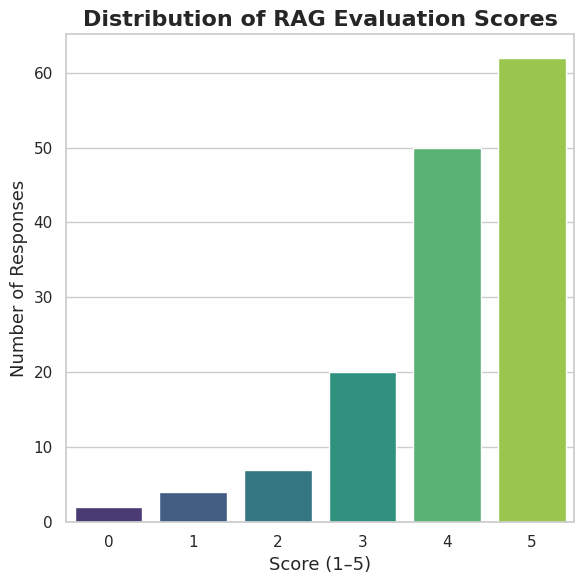

In [ ]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
# Calculate distribution
score_counts = Counter(scores)
sorted_scores = sorted(score_counts.items())

# Prepare data
x = [str(k) for k, v in sorted_scores]
y = [v for k, v in sorted_scores]

# Set seaborn style
sns.set(style="whitegrid")
palette = sns.color_palette("viridis", len(x))  # Or try "Set2", "coolwarm"

# Create the plot
plt.figure(figsize=(6, 6))
bars = sns.barplot(x=x, y=y, palette=palette)

# Titles and labels
plt.title("Distribution of RAG Evaluation Scores", fontsize=16, weight='bold')
plt.xlabel("Score (1–5)", fontsize=13)
plt.ylabel("Number of Responses", fontsize=13)
plt.tight_layout()

# Save and show
plt.savefig("rag_evaluation_advanced_chart.png", dpi=300)
plt.show()


In [ ]:
pip install sentence-transformers pandas scikit-learn

In [ ]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
model = SentenceTransformer("intfloat/multilingual-e5-base")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
import json

with open("eval.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df = df.rename(columns={
"generated_response": "answer",
"retrieved_context": "context"
})
df = df[["question", "answer", "context"]]
df.to_csv("rag_results.csv", index=False)
question_embeddings = model.encode(df["question"].tolist(), convert_to_tensor=True)
answer_embeddings = model.encode(df["answer"].tolist(), convert_to_tensor=True)
context_embeddings = model.encode(df["context"].tolist(), convert_to_tensor=True)

In [ ]:
faithfulness_scores = util.cos_sim(answer_embeddings, context_embeddings).diagonal()
relevance_scores = util.cos_sim(answer_embeddings, question_embeddings).diagonal()

In [ ]:
df["faithfulness"] = faithfulness_scores.cpu().numpy()
df["relevance"] = relevance_scores.cpu().numpy()

In [ ]:
print("Average Faithfulness Score:", df["faithfulness"].mean())
print("Average Relevance Score:", df["relevance"].mean())

Average Faithfulness Score: 0.90543824
Average Relevance Score: 0.8899258


In [ ]:
df.to_csv("rag_results.csv", index=False)